In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [33]:
model = load_model("models/modellov5_rumori.h5")

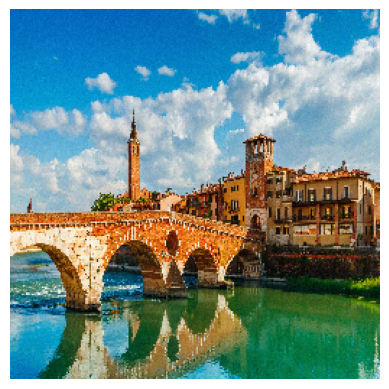

In [40]:
import tensorflow as tf
import matplotlib.pyplot as plt

img_path = 'verona_con_gaussiano.jpg'
img = tf.io.read_file(img_path)
img = tf.image.decode_jpeg(img, channels=3)  # Decodifica l'immagine in RGB
resized_img = tf.image.resize(img, (256, 256))
preprocessed_image = resized_img / 255.0

# Visualizza l'immagine
plt.imshow(preprocessed_image)  # Normalizza i valori dei pixel tra 0 e 1
plt.axis('off')  # Nasconde gli assi
plt.show()

In [41]:
prediction = model.predict(np.expand_dims(preprocessed_image, axis=0))

1/1 [==============================] - 0s 44ms/step


In [42]:
prediction

array([[3.9768167e-17, 9.9530834e-01, 6.7631944e-32, 4.6916897e-03,
        0.0000000e+00]], dtype=float32)

In [43]:
class_labels = ['rumore_esponenziale', 'rumore_gaussiano', 'rumore_non_uniforme', 'rumore_sale_e_pepe', 'rumore_uniforme']  # Lista delle classi di rumore
predicted_class_index = np.argmax(prediction)
predicted_class_label = class_labels[predicted_class_index]

In [44]:
predicted_class_label

'rumore_gaussiano'